### The missing piece of the model: Non-Linearity

'What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?'

or in machine learning terms, an infinite (but really it is finite) Linear and non-linear functions.


### Recreating non-linear data (red and blue circles)



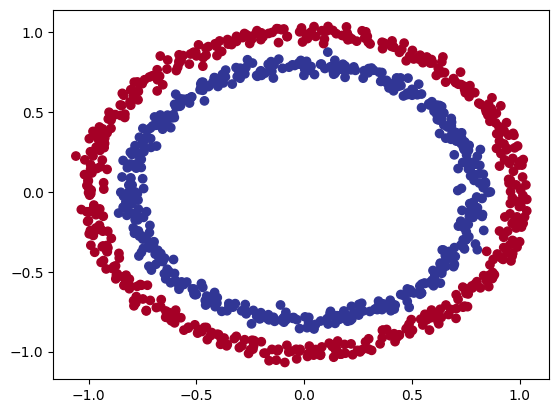

In [21]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import numpy as np

n_samples = 1000

X, y = make_circles(n_samples, 
                    noise = 0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [22]:
# Convert data to tensors and then to train and test splits
import torch 
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                     random_state=42)

device = "cuda" if torch.cuda.is_available() else "cpu"
X_train[:5], y_train[:5]



(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [23]:
### Useful functions 

# Calculate Accuracy - what percentage of the test data did the model predict right? 
# Accuracy = True positive/(True Positive + True Negative) * 100

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc



def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor): 
    
    # Put everything to cpu
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup decision boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))
    
    # Make features 
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make Predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)
        
        # Test for Multi_class or binary classifications and adjust logits to prediction labels
        if len(torch.unique(y)) > 2:
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # Multi-class
        else:
            y_pred = torch.round(torch.sigmoid(y_logits))  # Binary 
        
        # Reshape preds and plot
        y_pred = y_pred.reshape(xx.shape).detach().numpy()
        plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha = 0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap= plt.cm.RdYlBu)
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())

# Building a model with non_linearity 

* Linear =  straight line 
* Non-linear = non-straight lines 

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [24]:
# Build a model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super(). __init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)

In [25]:
loss_fn = nn.BCEWithLogitsLoss()
optimiser = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.01)


In [26]:
# Setting random seeds 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [34]:
### Training The Model
epochs = 10000

for epoch in range(epochs):
    model_3.train()
    
    model_3_logits = model_3(X_train).squeeze()
    model_3_pred = torch.round(torch.sigmoid(model_3_logits))  

    loss = loss_fn(model_3_logits, y_train) # BCEWithLogitsLoss (takes in logits as first input)
    acc = accuracy_fn(y_true = y_train,
                      y_pred = model_3_pred)
    
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # Testing 
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn (y_true=y_test,
                                y_pred= test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% ")
 
            

Epoch: 0 | Loss: 0.3759, Acc: 97.75% | Test Loss: 0.4114, Test Acc: 92.00% 
Epoch: 100 | Loss: 0.3642, Acc: 98.12% | Test Loss: 0.4014, Test Acc: 93.00% 
Epoch: 200 | Loss: 0.3523, Acc: 98.12% | Test Loss: 0.3914, Test Acc: 93.00% 
Epoch: 300 | Loss: 0.3403, Acc: 98.38% | Test Loss: 0.3815, Test Acc: 93.50% 
Epoch: 400 | Loss: 0.3281, Acc: 98.38% | Test Loss: 0.3716, Test Acc: 93.50% 
Epoch: 500 | Loss: 0.3161, Acc: 98.50% | Test Loss: 0.3613, Test Acc: 94.50% 
Epoch: 600 | Loss: 0.3043, Acc: 98.50% | Test Loss: 0.3509, Test Acc: 95.00% 
Epoch: 700 | Loss: 0.2927, Acc: 98.62% | Test Loss: 0.3405, Test Acc: 95.50% 
Epoch: 800 | Loss: 0.2812, Acc: 98.88% | Test Loss: 0.3302, Test Acc: 95.50% 
Epoch: 900 | Loss: 0.2700, Acc: 99.00% | Test Loss: 0.3195, Test Acc: 95.50% 
Epoch: 1000 | Loss: 0.2593, Acc: 99.00% | Test Loss: 0.3090, Test Acc: 96.00% 
Epoch: 1100 | Loss: 0.2491, Acc: 99.00% | Test Loss: 0.2987, Test Acc: 96.50% 
Epoch: 1200 | Loss: 0.2393, Acc: 99.25% | Test Loss: 0.2888, Tes

In [35]:
# Making prediction
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

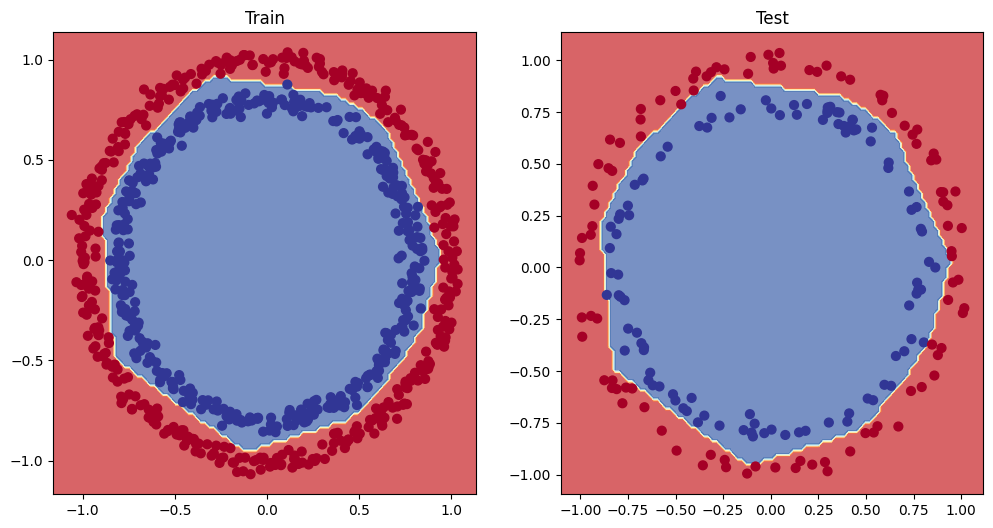

In [36]:
# Plot decision boundary 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)
